<a href="https://colab.research.google.com/github/jewon6273-creator/quant-/blob/main/disclosure_event_study_buyback_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 공시 이벤트 스터디 ① 자사주 매입 공시 (v2: 강건성 검증 추가)

**질문:** 자사주 매입 공시는 정말 호재인가? 어떤 자사주 매입이 효과가 있나?

- 데이터: DART Open API(공시) + FinanceDataReader/pykrx(주가)
- 방법: 시장조정 초과수익률(주식 수익률 − 코스피/코스닥 지수 수익률)
- 비교: 직접취득 vs 신탁계약, 소각 목적 여부, 코스피 vs 코스닥, 기간 분할

**실행 순서:** 위에서부터 차례로 실행하세요. `0. 준비` → `테스트` → `1~5단계`.

**DART API 키 받기:** opendart.fss.or.kr 회원가입 → 인증키 신청 (무료).  
Colab 왼쪽 🔑(보안 비밀)에 이름 `DART_API_KEY`로 저장하면 코드에 키를 적지 않아도 됩니다.

## 0. 준비

In [1]:
!pip install -q finance-datareader pykrx
!apt-get -qq install -y fonts-nanum > /dev/null
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'; plt.rcParams['axes.unicode_minus'] = False

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.6 MB/s eta 0:00:00


In [2]:
# ===== 설정 =====
QUICK = True            # True: 최근 2년만 빠르게 (처음엔 이걸로 전체 흐름 확인) / False: 전체 기간
START, END = ('2024-07-01', '2026-08-31') if QUICK else ('2016-01-01', '2026-08-31')

PRE, POST   = 5, 20     # 이벤트 창: 공시 5거래일 전 ~ 20거래일 후
HOLD        = 20        # 매매 테스트 보유기간(거래일)
COST        = 0.003     # 왕복 거래비용 가정 0.3% (수수료+거래세+슬리피지, 본인 조건에 맞게 조정)
DEDUP_DAYS  = 30        # 같은 종목이 30일 안에 또 공시하면 첫 공시만 사용
SPLIT_DATE  = '2021-01-01'   # 기간 분할 기준

API_KEY = ''
if not API_KEY:
    try:
        from google.colab import userdata; API_KEY = userdata.get('DART_API_KEY')
    except Exception:
        pass
if not API_KEY:
    from getpass import getpass; API_KEY = getpass('DART API 키: ')
print('기간:', START, '~', END)

기간: 2024-07-01 ~ 2026-08-31


In [3]:
# ===== 핵심 함수 모음 (이 셀은 수정할 필요 없음) =====
import time, warnings
import numpy as np
import pandas as pd
import requests
warnings.filterwarnings("ignore")

DART_LIST_URL = "https://opendart.fss.or.kr/api/list.json"
DART_AQ_URL   = "https://opendart.fss.or.kr/api/tsstkAqDecsn.json"   # 자기주식 취득 결정 상세
DAILY_LIMIT   = 0.305   # 한국 가격제한폭 ±30%. 이보다 큰 일간 변동 = 액면분할·감자 등 기업행위로 간주

# ---------- 1. DART 수집 ----------
def date_chunks(start, end, days=85):
    """corp_code 없이 공시검색하면 기간이 3개월로 제한되므로 85일 단위로 쪼갠다."""
    s, e = pd.Timestamp(start), pd.Timestamp(end)
    out = []
    while s <= e:
        ce = min(s + pd.Timedelta(days=days), e)
        out.append((s.strftime("%Y%m%d"), ce.strftime("%Y%m%d")))
        s = ce + pd.Timedelta(days=1)
    return out

def dart_get(url, params, api_key, retries=3):
    p = dict(params); p["crtfc_key"] = api_key
    last = None
    for i in range(retries):
        try:
            return requests.get(url, params=p, timeout=30).json()
        except Exception as ex:
            last = ex; time.sleep(2 * (i + 1))
    raise RuntimeError(f"DART 요청 실패: {last}")

def fetch_disclosures(api_key, start, end, keyword="자기주식취득", sleep=0.15, verbose=True):
    """주요사항보고서(pblntf_ty=B) 중 보고서명에 keyword가 들어간 공시를 전부 수집."""
    rows, chunks = [], date_chunks(start, end)
    for k, (bgn, en) in enumerate(chunks, 1):
        page = 1
        while True:
            j = dart_get(DART_LIST_URL, dict(bgn_de=bgn, end_de=en, pblntf_ty="B",
                                             page_no=page, page_count=100), api_key)
            st = j.get("status")
            if st == "013":            # 조회 결과 없음
                break
            if st != "000":
                raise RuntimeError(f"DART 오류 {st}: {j.get('message')}")
            for it in j.get("list", []):
                if keyword in it.get("report_nm", "").replace(" ", ""):
                    rows.append(it)
            if page >= int(j.get("total_page", 1)):
                break
            page += 1; time.sleep(sleep)
        if verbose:
            print(f"[{k}/{len(chunks)}] {bgn}~{en} 누적 {len(rows)}건")
        time.sleep(sleep)
    return pd.DataFrame(rows)

def dedupe(df, days=30):
    """같은 종목이 days일 안에 다시 공시하면 첫 번째만 남긴다 (이벤트 겹침 방지)."""
    keep, last = [], {}
    for idx, r in df.sort_values("event_date").iterrows():
        c, d = r["stock_code"], r["event_date"]
        if c in last and (d - last[c]).days < days:
            continue
        keep.append(idx); last[c] = d
    return df.loc[keep]

def clean_events(raw, dedup_days=30):
    df = raw.copy()
    nm = df["report_nm"].str.replace(" ", "")
    df = df[nm.str.contains("결정") & ~nm.str.contains("정정|처분|해지|결과|연장")]   # 원공시만 (연장결정은 새 정보가 아니므로 제외)
    df = df[df["stock_code"].fillna("").str.strip().str.len() == 6]
    df = df[df["corp_cls"].isin(["Y", "K"])].copy()                            # 코스피·코스닥만
    df["event_date"] = pd.to_datetime(df["rcept_dt"])
    df["type"]   = np.where(df["report_nm"].str.replace(" ", "").str.contains("신탁"), "신탁", "직접")
    df["market"] = df["corp_cls"].map({"Y": "KOSPI", "K": "KOSDAQ"})
    df = dedupe(df, dedup_days)
    return df[["rcept_no", "corp_code", "corp_name", "stock_code", "market",
               "type", "report_nm", "event_date"]].reset_index(drop=True)

def fetch_cancel_purpose(api_key, events, sleep=0.12, verbose=True):
    """직접취득 공시의 상세 내용에서 '소각' 언급 여부를 찾는다 (필드명이 바뀌어도 동작하도록 전체 텍스트 검색)."""
    found = {}
    g = events[events["type"] == "직접"].groupby("corp_code")
    for k, (corp, sub) in enumerate(g, 1):
        j = dart_get(DART_AQ_URL, dict(corp_code=corp,
                                       bgn_de=sub.event_date.min().strftime("%Y%m%d"),
                                       end_de=sub.event_date.max().strftime("%Y%m%d")), api_key)
        if j.get("status") == "000":
            for it in j.get("list", []):
                found[it.get("rcept_no")] = "소각" in " ".join(str(v) for v in it.values())
        if verbose and k % 100 == 0:
            print(f"  상세 조회 {k}/{g.ngroups}")
        time.sleep(sleep)
    out = events.copy()
    out["cancel"] = out["rcept_no"].map(found)          # True / False / NaN(조회 실패)
    return out

# ---------- 2. 가격 ----------
def load_px(code, start, end):
    """종가·거래량 DataFrame(Close, Volume). FinanceDataReader → pykrx 순으로 시도. 실패하면 None."""
    try:
        import FinanceDataReader as fdr
        d = fdr.DataReader(code, start, end)
        if d is not None and len(d) and "Close" in d:
            return pd.DataFrame({"Close": d["Close"].astype(float),
                                 "Volume": d["Volume"].astype(float) if "Volume" in d else np.nan})
    except Exception:
        pass
    try:
        from pykrx import stock
        d = stock.get_market_ohlcv(pd.Timestamp(start).strftime("%Y%m%d"),
                                   pd.Timestamp(end).strftime("%Y%m%d"), code)
        if len(d):
            return pd.DataFrame({"Close": d["종가"].astype(float), "Volume": d["거래량"].astype(float)})
    except Exception:
        pass
    return None

def load_index(market, start, end):
    fdr_code, krx_code = {"KOSPI": ("KS11", "1001"), "KOSDAQ": ("KQ11", "2001")}[market]
    try:
        import FinanceDataReader as fdr
        d = fdr.DataReader(fdr_code, start, end)
        if len(d): return d["Close"].astype(float)
    except Exception:
        pass
    from pykrx import stock
    d = stock.get_index_ohlcv(pd.Timestamp(start).strftime("%Y%m%d"),
                              pd.Timestamp(end).strftime("%Y%m%d"), krx_code)
    return d["종가"].astype(float)

# ---------- 3. 이벤트 스터디 ----------
def align(stock, mkt):
    idx = stock.dropna().index.intersection(mkt.dropna().index)
    return stock.loc[idx], mkt.loc[idx]

def event_pos(index, event_date):
    """공시일 이상인 첫 거래일의 위치 = t0 (주말·휴일 공시는 다음 거래일)."""
    return int(index.searchsorted(pd.Timestamp(event_date)))

def abnormal_returns(stock, mkt, event_date, pre=5, post=20):
    """시장조정 초과수익률 AR_t = r_주식 - r_지수, t = -pre..+post.
    반환: (Series 또는 None, 사유)"""
    s, m = align(stock, mkt)
    if len(s) < pre + post + 3:
        return None, "데이터부족"
    pos = event_pos(s.index, event_date)
    if pos - pre < 1 or pos + post >= len(s):
        return None, "기간밖"
    rs, rm = s.pct_change(), m.pct_change()
    win = slice(pos - pre, pos + post + 1)
    if np.any(np.abs(rs.iloc[win].values) > DAILY_LIMIT):
        return None, "기업행위의심"
    ar = (rs - rm).iloc[win].values
    return pd.Series(ar, index=range(-pre, post + 1)), "ok"

def tradable_return(stock, mkt, event_date, hold=20, cost=0.003, delay=1):
    """실제로 따라할 수 있는 매매: t0+delay 거래일 종가 매수 → hold일 후 종가 매도 (기본 delay=1).
    공시 시각을 모르므로 t0+1 종가 진입이면 장중·장후 공시 모두 미래정보 없음. 지수 대비 초과수익 - 왕복비용."""
    s, m = align(stock, mkt)
    pos = event_pos(s.index, event_date)
    a, b = pos + delay, pos + delay + hold
    if b >= len(s):
        return np.nan
    rs = s.pct_change().iloc[a + 1:b + 1]
    if np.any(np.abs(rs.values) > DAILY_LIMIT):
        return np.nan
    return (s.iloc[b] / s.iloc[a] - 1) - (m.iloc[b] / m.iloc[a] - 1) - cost

PX, IDX = {}, {}   # 3단계에서 채워지는 가격 캐시 (6단계 검증에서 재사용)

def build_ar_matrix(events, pre=5, post=20, hold=20, cost=0.003, pad_days=250, verbose=True):
    """pad_days: 공시 전후로 넉넉히 받아 둔다 (6단계 플라시보용 무작위 날짜를 뽑기 위해)."""
    ev = events.copy()
    lo = ev.event_date.min() - pd.Timedelta(days=pad_days)
    hi = ev.event_date.max() + pd.Timedelta(days=pad_days)
    PX.clear(); IDX.clear()
    for mk in ev.market.unique():
        IDX[mk] = load_index(mk, lo, hi)
    reasons, trade, liq, ars = {}, {}, {}, {}
    groups = ev.groupby("stock_code")
    for k, (code, sub) in enumerate(groups, 1):
        p = load_px(code, sub.event_date.min() - pd.Timedelta(days=pad_days),
                    sub.event_date.max() + pd.Timedelta(days=pad_days))
        if p is not None:
            PX[code] = p
        for i, r in sub.iterrows():
            if p is None:
                reasons[i] = "가격없음"; continue
            ar, why = abnormal_returns(p["Close"], IDX[r.market], r.event_date, pre, post)
            reasons[i] = why
            if ar is not None:
                ars[i] = ar
            trade[i] = tradable_return(p["Close"], IDX[r.market], r.event_date, hold, cost)
            # 공시 직전 20거래일 평균 거래대금(원) — 공시 이전 정보만 사용
            pos = event_pos(p.index, r.event_date)
            w = p.iloc[max(0, pos - 20):pos]
            liq[i] = (w["Close"] * w["Volume"]).mean() if len(w) >= 10 else np.nan
        if verbose and k % 100 == 0:
            print(f"  가격 처리 {k}/{groups.ngroups}")
    ev["status"] = pd.Series(reasons)
    ev["trade_ret"] = pd.Series(trade)
    ev["liq"] = pd.Series(liq)
    ev["year"] = ev.event_date.dt.year
    ar_mat = pd.DataFrame(ars).T.sort_index()
    return ev, ar_mat

# ---------- 4. 통계 ----------
def tstat(x):
    x = pd.Series(x).dropna()
    if len(x) < 3 or x.std(ddof=1) == 0:
        return np.nan
    return x.mean() / (x.std(ddof=1) / np.sqrt(len(x)))

WINDOWS = {"사전[-5,-1]": (-5, -1), "반응[0,+1]": (0, 1), "사후[+2,+20]": (2, 20), "전체[0,+20]": (0, 20)}

def car(ar_mat, a, b):
    cols = [c for c in ar_mat.columns if a <= c <= b]
    return ar_mat[cols].sum(axis=1)

def summary_table(ar_mat, events, by=None):
    """그룹별 구간 CAR 평균(%), t값, 양수 비율. t(날짜군집)은 같은 날 몰린 공시를 날짜별로 평균낸 뒤 계산 → 더 보수적."""
    ev = events.loc[ar_mat.index]
    keys = [("전체", ev.index)] if by is None else [(g, s.index) for g, s in ev.groupby(by)]
    out = []
    for g, ix in keys:
        row = {"그룹": g, "N": len(ix)}
        for name, (a, b) in WINDOWS.items():
            c = car(ar_mat.loc[ix], a, b)
            by_date = c.groupby(ev.loc[ix, "event_date"]).mean()
            row[f"{name} 평균%"] = round(c.mean() * 100, 2)
            row[f"{name} t"] = round(tstat(c), 2)
            row[f"{name} t(날짜군집)"] = round(tstat(by_date), 2)
        row["전체 양수비율%"] = round((car(ar_mat.loc[ix], 0, 20) > 0).mean() * 100, 1)
        out.append(row)
    return pd.DataFrame(out).set_index("그룹")

def plot_caar(ar_mat, events=None, by=None, title="자사주 매입 공시 전후 누적초과수익률(CAAR)"):
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(9, 5))
    ev = events.loc[ar_mat.index] if events is not None else None
    groups = [("전체", ar_mat)] if by is None else [(g, ar_mat.loc[s.index]) for g, s in ev.groupby(by)]
    for g, m in groups:
        c = m.cumsum(axis=1)
        mean = c.mean() * 100
        se = c.std(ddof=1) / np.sqrt(len(c)) * 100
        ax.plot(mean.index, mean.values, label=f"{g} (N={len(m)})")
        ax.fill_between(mean.index, mean - 1.96 * se, mean + 1.96 * se, alpha=0.15)
    ax.axvline(0, color="gray", ls="--"); ax.axhline(0, color="gray", lw=0.8)
    ax.set_xlabel("공시 기준 거래일 (0 = 공시일)"); ax.set_ylabel("누적 초과수익률 (%)")
    ax.set_title(title); ax.legend(); plt.show()

def trade_stats(x):
    x = pd.Series(x).dropna()
    return pd.Series({"N": len(x), "평균%": round(x.mean() * 100, 2), "중앙값%": round(x.median() * 100, 2),
                      "t": round(tstat(x), 2), "승률%": round((x > 0).mean() * 100, 1)})

def by_group(ev, ret, by=("market", "type")):
    return ev.assign(_r=ret).groupby(list(by))._r.apply(trade_stats).unstack()

def welch_t(a, b):
    a, b = pd.Series(a).dropna(), pd.Series(b).dropna()
    if len(a) < 3 or len(b) < 3:
        return np.nan
    return (a.mean() - b.mean()) / np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))

# ---------- 5. 강건성 검증 ----------
def _need_cache():
    assert PX and IDX, "3단계(build_ar_matrix)를 먼저 실행하세요."

def trades_with(ev, delay=1, hold=20, cost=0.003):
    """캐시된 가격으로 진입 지연·보유기간·비용을 바꿔 매매 수익을 다시 계산."""
    _need_cache()
    out = {}
    for i, r in ev.iterrows():
        p = PX.get(r.stock_code)
        out[i] = np.nan if p is None else tradable_return(p["Close"], IDX[r.market], r.event_date, hold, cost, delay)
    return pd.Series(out)

def placebo_trades(ev, draws=5, hold=20, cost=0.003, gap=40, seed=0):
    """같은 종목, 공시와 gap거래일 이상 떨어진 무작위 날짜에 똑같은 매매를 한다.
    여기서도 비슷하게 벌리면 '공시 효과'가 아니라 '그런 종목이 원래 잘 오른 것'."""
    _need_cache()
    rng = np.random.default_rng(seed)
    rows = []
    for code, sub in ev.groupby("stock_code"):
        p = PX.get(code)
        if p is None:
            continue
        mk = sub.market.iloc[0]
        s, m = align(p["Close"], IDX[mk])
        idx = s.index
        ev_pos = [event_pos(idx, d) for d in sub.event_date]
        cand = [k for k in range(25, len(idx) - hold - 2) if all(abs(k - e) > gap for e in ev_pos)]
        if not cand:
            continue
        for _, r in sub.iterrows():
            for k in rng.choice(cand, size=min(draws, len(cand)), replace=False):
                rows.append({"market": mk, "type": r["type"], "stock_code": code,
                             "trade_ret": tradable_return(s, m, idx[k], hold, cost, 1)})
    return pd.DataFrame(rows)

## 테스트 — 실제 데이터 전에 계산이 맞는지 확인
가짜 데이터로 ① 초과수익률 계산 ② 주말 공시 처리 ③ **미래 정보 미사용** ④ 액면분할 등 필터를 검증합니다. 하나라도 실패하면 결과를 믿지 마세요.

In [4]:
# ===== 검증 테스트: 실제 데이터 전에 반드시 통과해야 함 =====
def _synthetic(n=80, start="2024-01-01"):
    idx = pd.bdate_range(start, periods=n)
    mkt = pd.Series(100 * np.cumprod(np.full(n, 1.001)), index=idx)
    return idx, mkt

def test_date_chunks():
    ch = date_chunks("2020-01-01", "2020-12-31")
    days = pd.DatetimeIndex([])
    for a, b in ch:
        days = days.append(pd.date_range(a, b))
    assert days.is_unique and days.min() == pd.Timestamp("2020-01-01") and days.max() == pd.Timestamp("2020-12-31")
    assert all((pd.Timestamp(b) - pd.Timestamp(a)).days <= 90 for a, b in ch)

def test_weekend_maps_to_next_trading_day():
    idx, _ = _synthetic()
    sat = idx[10] + pd.Timedelta(days=(5 - idx[10].weekday()) % 7)
    assert sat.weekday() == 5
    assert idx[event_pos(idx, sat)].weekday() == 0

def test_known_jump_is_measured():
    idx, mkt = _synthetic()
    r = np.full(len(idx), 0.001); t0 = 30; r[t0] += 0.05
    stock = pd.Series(100 * np.cumprod(1 + r), index=idx)
    ar, why = abnormal_returns(stock, mkt, idx[t0], 5, 20)
    assert why == "ok"
    assert abs(ar[0] - 0.05) < 1e-9 and np.allclose(ar.drop(0).values, 0, atol=1e-12)

def test_no_lookahead_in_trade():
    """공시일 당일 +10% 급등은 t0+1 종가 진입 매매에 포함되면 안 된다."""
    idx, mkt = _synthetic()
    r = np.full(len(idx), 0.001); t0 = 30; r[t0] += 0.10
    stock = pd.Series(100 * np.cumprod(1 + r), index=idx)
    tr = tradable_return(stock, mkt, idx[t0], hold=20, cost=0.0)
    assert abs(tr) < 1e-9, f"미래정보 사용 의심: {tr}"

def test_after_entry_move_is_captured():
    idx, mkt = _synthetic()
    r = np.full(len(idx), 0.001); t0 = 30; r[t0 + 2] += 0.10
    stock = pd.Series(100 * np.cumprod(1 + r), index=idx)
    tr = tradable_return(stock, mkt, idx[t0], hold=20, cost=0.003)
    assert 0.09 < tr < 0.11

def test_corporate_action_filtered():
    idx, mkt = _synthetic()
    r = np.full(len(idx), 0.001); r[32] = -0.5
    stock = pd.Series(100 * np.cumprod(1 + r), index=idx)
    ar, why = abnormal_returns(stock, mkt, idx[30], 5, 20)
    assert ar is None and why == "기업행위의심"
    assert np.isnan(tradable_return(stock, mkt, idx[30], hold=20))

def test_delay_skips_earlier_move():
    """진입을 3일 늦추면 t0+2일의 급등은 수익에 포함되면 안 된다."""
    idx, mkt = _synthetic()
    r = np.full(len(idx), 0.001); t0 = 30; r[t0 + 2] += 0.10
    stock = pd.Series(100 * np.cumprod(1 + r), index=idx)
    assert abs(tradable_return(stock, mkt, idx[t0], hold=20, cost=0.0, delay=3)) < 1e-9

def test_clean_excludes_extension():
    raw = pd.DataFrame({"report_nm": ["주요사항보고서(자기주식취득신탁계약체결결정)",
                                      "[연장결정]주요사항보고서(자기주식취득신탁계약체결결정)",
                                      "[기재정정]주요사항보고서(자기주식취득결정)"],
                        "stock_code": ["000001", "000002", "000003"], "corp_cls": ["K"] * 3,
                        "rcept_dt": ["20240102"] * 3, "rcept_no": ["1", "2", "3"],
                        "corp_code": ["a", "b", "c"], "corp_name": ["A", "B", "C"]})
    out = clean_events(raw)
    assert list(out.stock_code) == ["000001"] and out.type.iloc[0] == "신탁"

def test_dedupe():
    df = pd.DataFrame({"stock_code": ["000001"] * 3 + ["000002"],
                       "event_date": pd.to_datetime(["2024-01-01", "2024-01-10", "2024-03-01", "2024-01-05"])})
    assert len(dedupe(df, 30)) == 3

for _t in [test_date_chunks, test_weekend_maps_to_next_trading_day, test_known_jump_is_measured,
           test_no_lookahead_in_trade, test_after_entry_move_is_captured,
           test_corporate_action_filtered, test_delay_skips_earlier_move,
           test_clean_excludes_extension, test_dedupe]:
    _t(); print("통과:", _t.__name__)
print("\n모든 테스트 통과 ✅")

통과: test_date_chunks
통과: test_weekend_maps_to_next_trading_day
통과: test_known_jump_is_measured
통과: test_no_lookahead_in_trade
통과: test_after_entry_move_is_captured
통과: test_corporate_action_filtered
통과: test_delay_skips_earlier_move
통과: test_clean_excludes_extension
통과: test_dedupe

모든 테스트 통과 ✅


## 1단계. 자사주 매입 공시 수집
처음 한 번만 DART에서 받고 `cache/`에 저장합니다. 전체 기간은 수 분 걸립니다.

In [5]:
import os
os.makedirs('cache', exist_ok=True)
raw_path = f'cache/raw_{START}_{END}.csv'
if os.path.exists(raw_path):
    raw = pd.read_csv(raw_path, dtype=str)
else:
    raw = fetch_disclosures(API_KEY, START, END)
    raw.to_csv(raw_path, index=False)

events = clean_events(raw, DEDUP_DAYS)
events['period'] = np.where(events.event_date < SPLIT_DATE, f'~{SPLIT_DATE[:4]} 이전', f'{SPLIT_DATE[:4]}~')
print(f'원자료 {len(raw)}건 → 정제 후 이벤트 {len(events)}건')
display(events.groupby(['market', 'type']).size().rename('건수').to_frame())
events.head()

[1/10] 20240701~20240924 누적 273건
[2/10] 20240925~20241219 누적 577건
[3/10] 20241220~20250315 누적 800건
[4/10] 20250316~20250609 누적 1031건
[5/10] 20250610~20250903 누적 1213건
[6/10] 20250904~20251128 누적 1364건
[7/10] 20251129~20260222 누적 1525건
[8/10] 20260223~20260519 누적 1694건
[9/10] 20260520~20260813 누적 2052건
[10/10] 20260814~20260831 누적 2092건
원자료 2092건 → 정제 후 이벤트 1207건


건수
market type     
KOSDAQ 신탁    496
       직접    272
KOSPI  신탁    208
       직접    231

,rcept_no,corp_code,corp_name,stock_code,market,type,report_nm,event_date,period
0,20240703000597,00119140,핸즈코퍼레이션,143210,KOSPI,직접,주요사항보고서(자기주식취득결정),2024-07-03,2021~
1,20240704000171,00506294,가비아,079940,KOSDAQ,신탁,주요사항보고서(자기주식취득신탁계약체결결정),2024-07-04,2021~
2,20240704000141,01367586,제이아이테크,417500,KOSDAQ,신탁,주요사항보고서(자기주식취득신탁계약체결결정),2024-07-04,2021~
3,20240704000178,00177199,디씨엠,024090,KOSPI,신탁,주요사항보고서(자기주식취득신탁계약체결결정),2024-07-04,2021~
4,20240705000007,00160588,한화,000880,KOSPI,직접,주요사항보고서(자기주식취득결정),2024-07-05,2021~


## 2단계 (선택). 소각 목적 여부 조회
직접취득 공시의 상세 내용에서 '소각' 언급을 찾습니다. 회사 수만큼 API를 호출하므로 시간이 걸립니다. 건너뛰어도 3단계는 돌아갑니다.

In [6]:
DO_CANCEL = True
cancel_path = f'cache/cancel_{START}_{END}.csv'
if DO_CANCEL:
    if os.path.exists(cancel_path):
        cm = pd.read_csv(cancel_path, dtype={'rcept_no': str})
        events['cancel'] = events.rcept_no.map(dict(zip(cm.rcept_no, cm.cancel)))
    else:
        events = fetch_cancel_purpose(API_KEY, events)
        events[['rcept_no', 'cancel']].to_csv(cancel_path, index=False)
    events['소각'] = events['cancel'].map({True: '소각 언급', False: '소각 없음'}).fillna('확인불가')
    display(events.groupby(['type', '소각']).size().rename('건수').to_frame())

  상세 조회 100/255
  상세 조회 200/255


건수
type 소각        
신탁   확인불가   704
직접   소각 언급   96
     소각 없음  312
     확인불가    95

## 3단계. 주가 붙이고 초과수익률 계산

In [7]:
ev_res, ar_mat = build_ar_matrix(events, PRE, POST, HOLD, COST)
print('처리 결과:'); display(ev_res.status.value_counts().to_frame('건수'))
miss = (ev_res.status == '가격없음').mean()
if miss > 0.05:
    print(f'⚠️ 가격을 못 구한 이벤트 {miss:.1%} — 대부분 상장폐지 종목일 가능성. 생존편향으로 결과가 좋게 나올 수 있음.')

  가격 처리 100/650
  가격 처리 200/650
  가격 처리 300/650
  가격 처리 400/650
  가격 처리 500/650
  가격 처리 600/650
처리 결과:


,건수
status,
ok,1191
기간밖,15
기업행위의심,1


## 4단계. 결과
- **사전[-5,-1]**: 공시 전에 이미 올랐나 (정보 유출·저가 매수 타이밍)
- **반응[0,+1]**: 공시 직후 반응 (공시 시각을 몰라 이틀 합산)
- **사후[+2,+20]**: 공시 뒤에도 계속 오르나 (따라 사도 되는 구간)
- **t(날짜군집)**: 같은 날 몰린 공시를 하나로 묶어 계산한 보수적 t값. |t|>2 정도는 돼야 의미 있다고 봅니다.

,N,"사전[-5,-1] 평균%","사전[-5,-1] t","사전[-5,-1] t(날짜군집)","반응[0,+1] 평균%","반응[0,+1] t","반응[0,+1] t(날짜군집)","사후[+2,+20] 평균%","사후[+2,+20] t","사후[+2,+20] t(날짜군집)","전체[0,+20] 평균%","전체[0,+20] t","전체[0,+20] t(날짜군집)",전체 양수비율%
그룹,,,,,,,,,,,,,,
전체,1191,-0.62,-2.83,-2.86,4.76,24.33,18.58,1.98,5.08,0.96,6.74,15.08,9.05,67.3


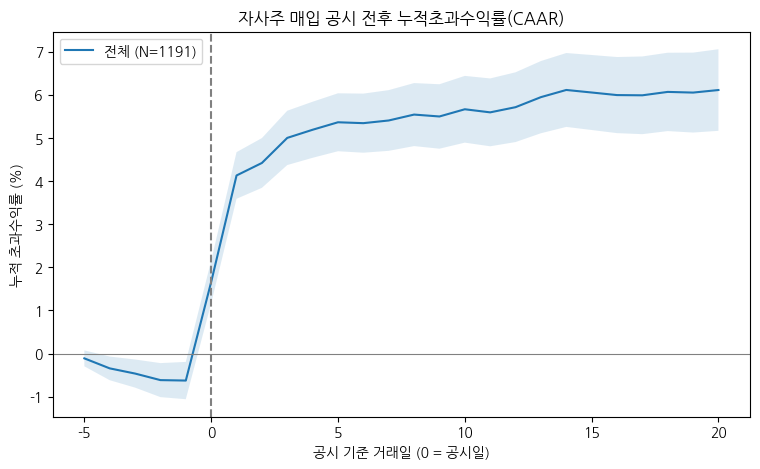

In [8]:
display(summary_table(ar_mat, ev_res))
plot_caar(ar_mat, ev_res)

,N,"사전[-5,-1] 평균%","사전[-5,-1] t","사전[-5,-1] t(날짜군집)","반응[0,+1] 평균%","반응[0,+1] t","반응[0,+1] t(날짜군집)","사후[+2,+20] 평균%","사후[+2,+20] t","사후[+2,+20] t(날짜군집)","전체[0,+20] 평균%","전체[0,+20] t","전체[0,+20] t(날짜군집)",전체 양수비율%
그룹,,,,,,,,,,,,,,
신탁,696,-0.60,-2.18,-1.44,4.44,18.31,14.94,3.34,6.50,3.82,7.78,13.32,9.68,69.4
직접,495,-0.66,-1.81,-2.00,5.21,16.09,14.63,0.07,0.11,-1.07,5.27,7.65,5.56,64.4


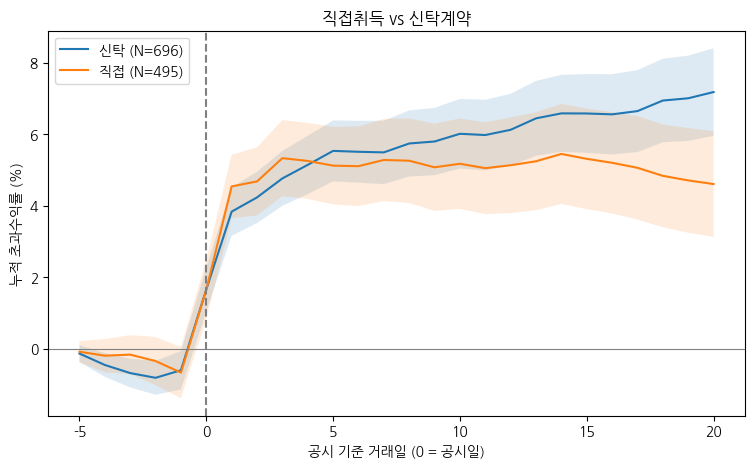

In [9]:
# 직접취득 vs 신탁계약
display(summary_table(ar_mat, ev_res, by='type'))
plot_caar(ar_mat, ev_res, by='type', title='직접취득 vs 신탁계약')

,N,"사전[-5,-1] 평균%","사전[-5,-1] t","사전[-5,-1] t(날짜군집)","반응[0,+1] 평균%","반응[0,+1] t","반응[0,+1] t(날짜군집)","사후[+2,+20] 평균%","사후[+2,+20] t","사후[+2,+20] t(날짜군집)","전체[0,+20] 평균%","전체[0,+20] t","전체[0,+20] t(날짜군집)",전체 양수비율%
그룹,,,,,,,,,,,,,,
소각 언급,94,-0.94,-1.30,-0.69,5.43,7.32,7.00,-1.03,-0.74,-1.14,4.40,2.63,2.36,56.4
소각 없음,308,-0.49,-1.01,-1.61,5.11,12.29,11.59,0.03,0.04,-1.07,5.14,6.02,4.44,66.6
확인불가,789,-0.64,-2.45,-1.87,4.54,19.73,16.11,3.10,6.38,3.64,7.64,13.91,9.98,68.9


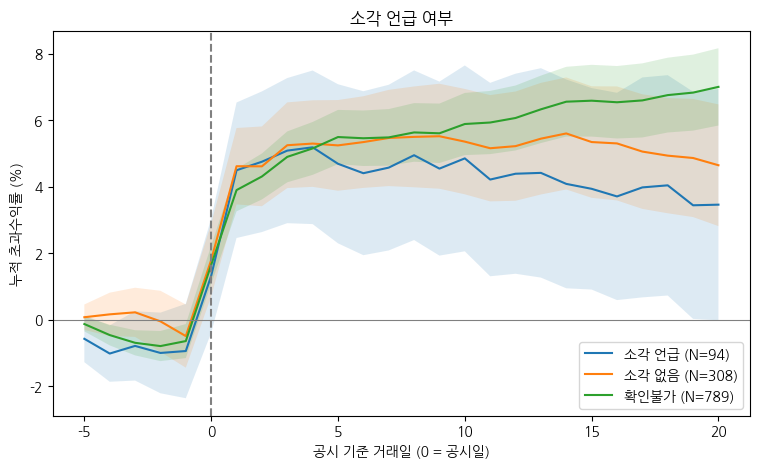

In [10]:
# 소각 목적 여부 (2단계를 실행한 경우)
if '소각' in ev_res:
    display(summary_table(ar_mat, ev_res, by='소각'))
    plot_caar(ar_mat, ev_res, by='소각', title='소각 언급 여부')

,N,"사전[-5,-1] 평균%","사전[-5,-1] t","사전[-5,-1] t(날짜군집)","반응[0,+1] 평균%","반응[0,+1] t","반응[0,+1] t(날짜군집)","사후[+2,+20] 평균%","사후[+2,+20] t","사후[+2,+20] t(날짜군집)","전체[0,+20] 평균%","전체[0,+20] t","전체[0,+20] t(날짜군집)",전체 양수비율%
그룹,,,,,,,,,,,,,,
KOSDAQ,760,-0.64,-2.24,-1.08,5.40,21.58,17.17,3.57,7.13,4.06,8.97,15.83,11.4,71.7
KOSPI,431,-0.60,-1.73,-2.33,3.62,11.89,10.70,-0.83,-1.39,-1.34,2.80,4.08,3.2,59.6


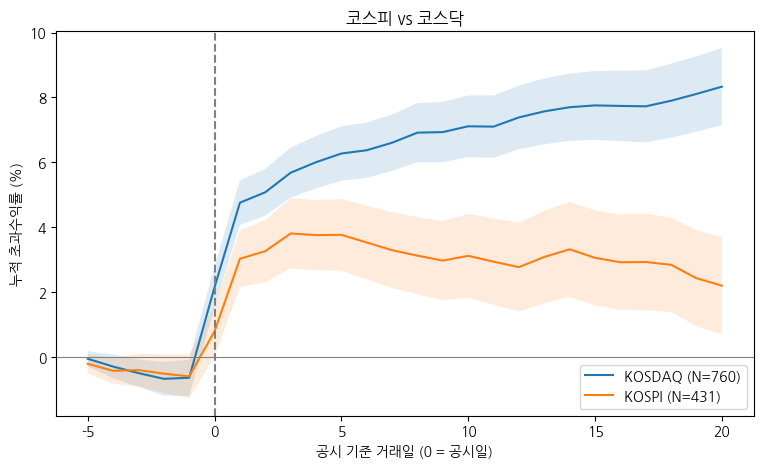

In [11]:
# 코스피 vs 코스닥
display(summary_table(ar_mat, ev_res, by='market'))
plot_caar(ar_mat, ev_res, by='market', title='코스피 vs 코스닥')

,N,"사전[-5,-1] 평균%","사전[-5,-1] t","사전[-5,-1] t(날짜군집)","반응[0,+1] 평균%","반응[0,+1] t","반응[0,+1] t(날짜군집)","사후[+2,+20] 평균%","사후[+2,+20] t","사후[+2,+20] t(날짜군집)","전체[0,+20] 평균%","전체[0,+20] t","전체[0,+20] t(날짜군집)",전체 양수비율%
그룹,,,,,,,,,,,,,,
2021~,1191,-0.62,-2.83,-2.86,4.76,24.33,18.58,1.98,5.08,0.96,6.74,15.08,9.05,67.3


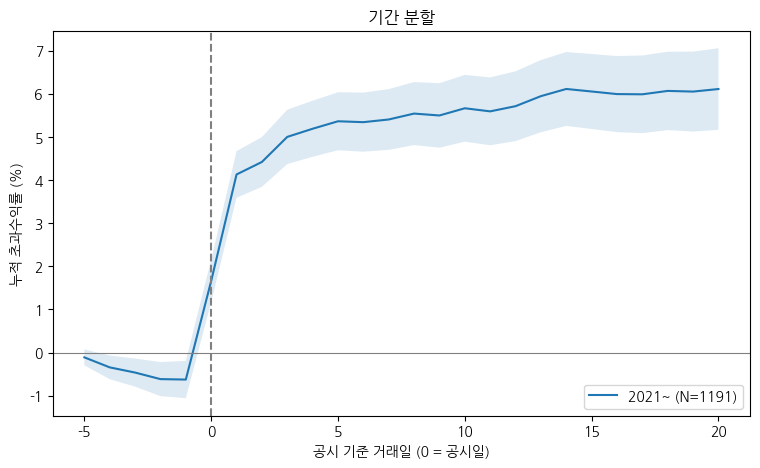

In [12]:
# 기간 분할 — 앞뒤 기간 결과가 엇갈리면 우연일 가능성이 큼 (QUICK 모드에선 한쪽만 나옴)
display(summary_table(ar_mat, ev_res, by='period'))
plot_caar(ar_mat, ev_res, by='period', title='기간 분할')

## 5단계. 따라 사면 돈이 되나 (비용 반영)
공시 다음 거래일 종가에 사서 HOLD일 뒤 종가에 파는 매매. 공시 시각과 무관하게 **미래 정보 없음**. 지수 대비 초과수익에서 왕복비용을 뺀 값입니다.

In [13]:
print(f'보유 {HOLD}거래일, 왕복비용 {COST:.1%}')
display(trade_stats(ev_res.trade_ret).to_frame('전체').T)
for col in ['type', 'market', 'period'] + (['소각'] if '소각' in ev_res else []):
    display(ev_res.groupby(col).trade_ret.apply(trade_stats).unstack())

보유 20거래일, 왕복비용 0.3%


,N,평균%,중앙값%,t,승률%
전체,1189.0,1.44,0.48,3.5,52.5


,N,평균%,중앙값%,t,승률%
type,,,,,
신탁,694.0,2.84,1.51,5.27,54.9
직접,495.0,-0.51,-0.17,-0.81,49.1


,N,평균%,중앙값%,t,승률%
market,,,,,
KOSDAQ,759.0,2.93,1.74,5.61,55.6
KOSPI,430.0,-1.18,-1.09,-1.82,47.0


,N,평균%,중앙값%,t,승률%
period,,,,,
2021~,1189.0,1.44,0.48,3.5,52.5


,N,평균%,중앙값%,t,승률%
소각,,,,,
소각 언급,94.0,-1.69,-1.37,-1.19,47.9
소각 없음,308.0,-0.37,0.03,-0.48,50.3
확인불가,787.0,2.53,0.93,4.91,53.9


## 6단계. 강건성 검증
후보 신호가 진짜인지 가짜인지 가립니다. 3단계를 실행한 뒤 순서대로 돌리세요 (가격을 다시 받지 않고 캐시를 씁니다).

### 6-1. 시장 × 유형 교차
신탁이라서 오르는지, 코스닥이라서 오르는지 가릅니다.

In [14]:
# ---- 6-1. 시장 × 유형 교차: 신탁 효과인가, 코스닥 효과인가 ----
print('【사후 구간 초과수익(이벤트 스터디)】')
display(summary_table(ar_mat, ev_res, by=['market', 'type'])[
    ['N', '반응[0,+1] 평균%', '사후[+2,+20] 평균%', '사후[+2,+20] t(날짜군집)', '전체 양수비율%']])
print('【따라 사는 매매 (t0+1 진입, 20일 보유, 비용 반영)】')
display(by_group(ev_res, ev_res.trade_ret))

【사후 구간 초과수익(이벤트 스터디)】


,N,"반응[0,+1] 평균%","사후[+2,+20] 평균%","사후[+2,+20] t(날짜군집)",전체 양수비율%
그룹,,,,,
"(KOSDAQ, 신탁)",492,4.76,4.47,4.33,72.2
"(KOSDAQ, 직접)",268,6.56,1.93,1.85,70.9
"(KOSPI, 신탁)",204,3.64,0.63,1.24,62.7
"(KOSPI, 직접)",227,3.61,-2.14,-2.53,56.8


【따라 사는 매매 (t0+1 진입, 20일 보유, 비용 반영)】


N   평균%  중앙값%     t   승률%
market type                               
KOSDAQ 신탁    491.0  3.83  2.33  5.64  57.0
       직접    268.0  1.29  0.44  1.62  53.0
KOSPI  신탁    203.0  0.45 -0.12  0.55  49.8
       직접    227.0 -2.64 -1.92 -2.67  44.5

### 6-2. 플라시보 (가장 중요)
같은 종목에 공시가 없는 무작위 날짜를 넣고 똑같이 매매합니다. 무작위 날짜에서도 비슷하게 벌면 공시 효과가 아닙니다. 종목당 5번 뽑아서 시간이 조금 걸립니다.

In [15]:
# ---- 6-2. 플라시보: 같은 종목, 공시 없는 무작위 날짜 ----
plc = placebo_trades(ev_res, draws=5, hold=HOLD, cost=COST)
rows = []
for (mk, tp), sub in ev_res.groupby(['market', 'type']):
    e = sub.trade_ret.dropna()
    p = plc[(plc.market == mk) & (plc.type == tp)].trade_ret.dropna()
    rows.append({'그룹': f'{mk}-{tp}', '공시 N': len(e), '공시 평균%': round(e.mean()*100, 2),
                 '무작위 N': len(p), '무작위 평균%': round(p.mean()*100, 2),
                 '차이%p': round((e.mean() - p.mean())*100, 2), '차이 t': round(welch_t(e, p), 2)})
display(pd.DataFrame(rows).set_index('그룹'))
print('→ "무작위 평균"도 높다면 공시가 아니라 종목 특성. "차이 t" > 2 정도는 돼야 공시 효과로 볼 수 있음.')

,공시 N,공시 평균%,무작위 N,무작위 평균%,차이%p,차이 t
그룹,,,,,,
KOSDAQ-신탁,491,3.83,2473,-1.21,5.04,6.62
KOSDAQ-직접,268,1.29,1355,-0.67,1.96,2.18
KOSPI-신탁,203,0.45,1040,-3.80,4.24,4.58
KOSPI-직접,227,-2.64,1155,-2.76,0.12,0.11


→ "무작위 평균"도 높다면 공시가 아니라 종목 특성. "차이 t" > 2 정도는 돼야 공시 효과로 볼 수 있음.


### 6-3. 연도별

In [16]:
# ---- 6-3. 연도별: 특정 해에만 몰려 있나 ----
yr = ev_res.assign(post=car(ar_mat, 2, 20)).groupby(['year', 'market', 'type']).agg(
    N=('trade_ret', 'count'), 매매평균=('trade_ret', lambda x: round(x.mean()*100, 2)),
    매매중앙값=('trade_ret', lambda x: round(x.median()*100, 2)))
display(yr.unstack(['market', 'type']))
print('→ 해마다 같은 방향이어야 신호. QUICK 모드는 연도가 적으니 QUICK=False로 다시 확인하세요.')

N                  매매평균                    매매중앙값                  
market KOSDAQ      KOSPI     KOSDAQ       KOSPI       KOSDAQ       KOSPI      
type       신탁   직접    신탁  직접     신탁    직접    신탁    직접     신탁    직접    신탁    직접
year                                                                          
2024      183   80    64  50   1.42  1.41  2.87  1.88   1.40  2.16  3.12  0.92
2025      131   88    75  99   0.14  0.40 -1.33 -4.41  -0.65 -0.42 -2.36 -4.82
2026      177  100    64  78   9.04  1.98  0.10 -3.30   7.06  0.53 -1.57 -1.30

→ 해마다 같은 방향이어야 신호. QUICK 모드는 연도가 적으니 QUICK=False로 다시 확인하세요.


### 6-4. 비용 민감도

In [17]:
# ---- 6-4. 비용 민감도 ----
rows = {}
for c in [0.003, 0.005, 0.01, 0.015]:
    r = ev_res.trade_ret + COST - c
    rows[f'비용 {c:.1%}'] = ev_res.assign(_r=r).groupby(['market', 'type'])._r.mean().mul(100).round(2)
display(pd.DataFrame(rows))

비용 0.3%  비용 0.5%  비용 1.0%  비용 1.5%
market type                                    
KOSDAQ 신탁       3.83     3.63     3.13     2.63
       직접       1.29     1.09     0.59     0.09
KOSPI  신탁       0.45     0.25    -0.25    -0.75
       직접      -2.64    -2.84    -3.34    -3.84

### 6-5. 유동성

In [18]:
# ---- 6-5. 유동성: 거래대금이 작은 종목에서만 나오는 수익인가 ----
ev_res['liq_q'] = pd.qcut(ev_res.liq, 5, labels=['1(최소)', '2', '3', '4', '5(최대)'])
print('【거래대금 5분위별 매매 수익】 (공시 직전 20일 평균 거래대금 기준)')
display(ev_res.groupby('liq_q').trade_ret.apply(trade_stats).unstack())
print('【거래대금 하위 40% 제외 후】')
display(by_group(ev_res[ev_res.liq >= ev_res.liq.quantile(0.4)], ev_res.trade_ret))

【거래대금 5분위별 매매 수익】 (공시 직전 20일 평균 거래대금 기준)


,N,평균%,중앙값%,t,승률%
liq_q,,,,,
1(최소),237.0,5.16,3.30,5.72,65.0
2,235.0,3.36,1.50,3.62,57.9
3,239.0,0.20,-0.75,0.25,47.3
4,239.0,-0.44,-1.38,-0.55,46.0
5(최대),237.0,-1.01,-1.45,-0.95,46.4


【거래대금 하위 40% 제외 후】


N   평균%  중앙값%     t   승률%
market type                               
KOSDAQ 신탁    270.0  1.47  0.10  1.75  50.7
       직접    132.0 -0.59 -2.14 -0.50  40.9
KOSPI  신탁    140.0 -0.67 -1.38 -0.68  47.1
       직접    173.0 -3.02 -2.46 -2.52  43.9

### 6-6. 극단값

In [19]:
# ---- 6-6. 극단값: 몇 개 대박이 평균을 만든 건가 ----
rows = []
for (mk, tp), sub in ev_res.groupby(['market', 'type']):
    x = sub.trade_ret.dropna()
    top_cut = x[x < x.quantile(0.95)]
    both_cut = x[(x > x.quantile(0.05)) & (x < x.quantile(0.95))]
    rows.append({'그룹': f'{mk}-{tp}', '원래 평균%': round(x.mean()*100, 2),
                 '상위5% 제거%': round(top_cut.mean()*100, 2), '양끝5% 제거%': round(both_cut.mean()*100, 2),
                 '중앙값%': round(x.median()*100, 2)})
display(pd.DataFrame(rows).set_index('그룹'))

,원래 평균%,상위5% 제거%,양끝5% 제거%,중앙값%
그룹,,,,
KOSDAQ-신탁,3.83,1.64,2.96,2.33
KOSDAQ-직접,1.29,-0.44,1.00,0.44
KOSPI-신탁,0.45,-1.13,0.09,-0.12
KOSPI-직접,-2.64,-4.61,-2.86,-1.92


### 6-7. 진입 지연 · 보유기간

In [20]:
# ---- 6-7. 진입 지연 · 보유기간: 신호가 언제 시작해서 언제 끝나나 ----
res_d = {f'{d}일 뒤 진입': ev_res.assign(_r=trades_with(ev_res, delay=d, hold=HOLD, cost=COST))
         .groupby(['market', 'type'])._r.mean().mul(100).round(2) for d in [1, 3, 5, 10]}
print(f'【진입 지연 (보유 {HOLD}일)】'); display(pd.DataFrame(res_d))
res_h = {f'{h}일 보유': ev_res.assign(_r=trades_with(ev_res, delay=1, hold=h, cost=COST))
         .groupby(['market', 'type'])._r.mean().mul(100).round(2) for h in [5, 10, 20, 40]}
print('【보유기간 (1일 뒤 진입)】'); display(pd.DataFrame(res_h))

【진입 지연 (보유 20일)】


1일 뒤 진입  3일 뒤 진입  5일 뒤 진입  10일 뒤 진입
market type                                     
KOSDAQ 신탁       3.83     3.09     2.78      1.41
       직접       1.29     0.20     0.26      0.30
KOSPI  신탁       0.45    -0.72    -0.84     -0.12
       직접      -2.64    -3.72    -3.46     -3.14

【보유기간 (1일 뒤 진입)】


5일 보유  10일 보유  20일 보유  40일 보유
market type                               
KOSDAQ 신탁     1.64    2.59    3.83    4.63
       직접     0.78    1.06    1.29    1.73
KOSPI  신탁     0.72    0.06    0.45   -0.60
       직접    -0.02   -0.64   -2.64   -5.28

### 6-8. 판정
후보 그룹이 7개 관문을 통과하는지 한 번에 봅니다. `TARGET`을 바꾸면 다른 그룹도 검증할 수 있습니다.

In [21]:
# ---- 6-8. 판정: 후보 신호가 관문을 모두 통과하나 ----
TARGET = ('KOSDAQ', '신탁')      # 검증할 후보 그룹
sel = lambda d: d[(d.market == TARGET[0]) & (d.type == TARGET[1])]
x = sel(ev_res).trade_ret.dropna()
p = sel(plc).trade_ret.dropna()
yr_mean = sel(ev_res).groupby('year').trade_ret.mean()
liq_ok = sel(ev_res[ev_res.liq >= ev_res.liq.quantile(0.4)]).trade_ret.dropna()
late = sel(ev_res.assign(_r=trades_with(ev_res, delay=5, hold=HOLD, cost=COST)))._r.dropna()
checks = {
    '① 무작위 날짜보다 유의하게 높음 (차이 t>2)': welch_t(x, p) > 2,
    '② 중앙값 > 0':                             x.median() > 0,
    '③ 상위 5% 제거해도 평균 > 0':              x[x < x.quantile(0.95)].mean() > 0,
    '④ 비용 1%에서도 평균 > 0':                 (x + COST - 0.01).mean() > 0,
    '⑤ 거래대금 하위 40% 빼도 평균 > 0':        liq_ok.mean() > 0,
    '⑥ 5일 늦게 사도 평균 > 0':                 late.mean() > 0,
    f'⑦ 연도별 플러스 비율 ≥ 70% ({len(yr_mean)}개 연도)': (yr_mean > 0).mean() >= 0.7,
}
print(f'후보: {TARGET[0]} {TARGET[1]} (N={len(x)}, 평균 {x.mean()*100:.2f}%)\n')
for k, v in checks.items():
    print(('✅ 통과  ' if v else '❌ 탈락  ') + k)
n = sum(checks.values())
print(f'\n{n}/{len(checks)} 통과 → ' + ('신호 후보 유지. 전체 기간(QUICK=False)으로 재확인하세요.' if n == len(checks)
      else '탈락한 항목이 왜 무너졌는지부터 확인하세요. ①이 탈락이면 공시 효과로 보기 어렵습니다.'))

후보: KOSDAQ 신탁 (N=491, 평균 3.83%)

✅ 통과  ① 무작위 날짜보다 유의하게 높음 (차이 t>2)
✅ 통과  ② 중앙값 > 0
✅ 통과  ③ 상위 5% 제거해도 평균 > 0
✅ 통과  ④ 비용 1%에서도 평균 > 0
✅ 통과  ⑤ 거래대금 하위 40% 빼도 평균 > 0
✅ 통과  ⑥ 5일 늦게 사도 평균 > 0
✅ 통과  ⑦ 연도별 플러스 비율 ≥ 70% (3개 연도)

7/7 통과 → 신호 후보 유지. 전체 기간(QUICK=False)으로 재확인하세요.


In [25]:
from google.colab import drive
drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/disclosure_cache', exist_ok=True)
os.chdir('/content/drive/MyDrive/disclosure_cache')

Mounted at /content/drive


In [26]:
!cp -r /content/cache /content/drive/MyDrive/disclosure_cache/
!ls /content/drive/MyDrive/disclosure_cache/cache

cancel_2024-07-01_2026-08-31.csv  raw_2024-07-01_2026-08-31.csv


Saving step7_addon.py to step7_addon.py
업로드된 파일: step7_addon.py
통과: test_portfolio_backtest ✅
신호 696건, 플라시보 695건


,연수익률%,변동성%,샤프,최대낙폭%,누적%
전략(주식만),18.76,23.82,0.84,-16.79,44.1
전략(지수 헤지),12.62,18.30,0.74,-23.79,28.7
플라시보(주식만),4.26,22.18,0.30,-25.52,9.2
플라시보(지수 헤지),-21.61,18.91,-1.19,-52.18,-40.2
KOSDAQ 지수,-1.45,37.63,0.15,-47.42,-3.0


평균 보유 종목 25.9개 / 투자 비중 평균 83% (나머지는 현금) / 종목이 하나도 없던 날 0%


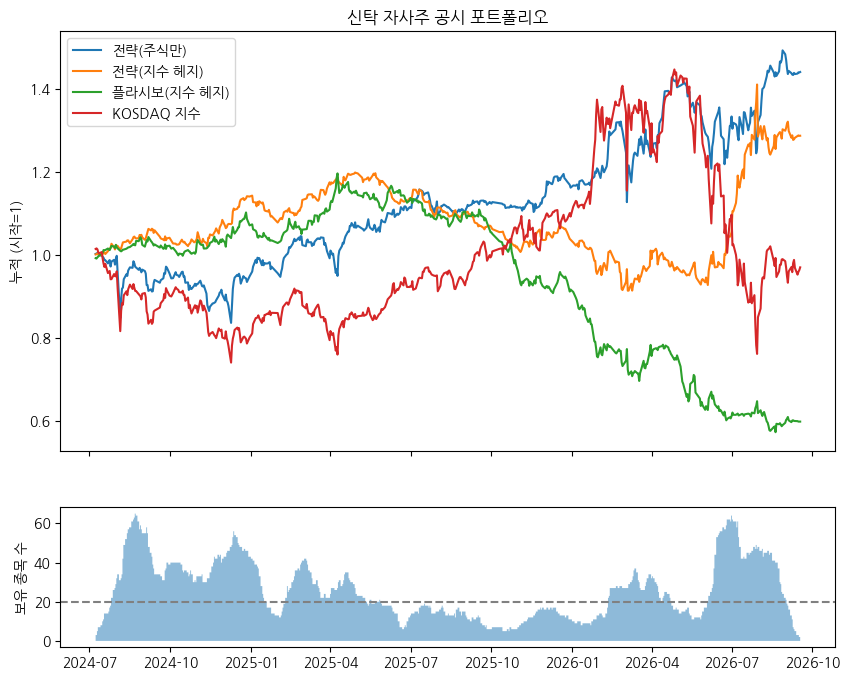

,전략(주식만)%,전략(헤지)%,플라시보(헤지)%,KOSDAQ%,평균 보유 종목
2024,-5.2,14.0,7.1,-20.0,38.381
2025,22.6,-9.1,-14.5,36.5,18.289
2026,24.0,24.2,-34.8,-11.2,28.029


,연수익률%,변동성%,샤프,최대낙폭%,누적%
슬롯 10 / 비용 0.3%,5.24,20.48,0.35,-33.30,11.5
슬롯 10 / 비용 1.0%,-3.71,20.47,-0.08,-38.98,-7.7
슬롯 20 / 비용 0.3%,12.62,18.30,0.74,-23.79,28.7
슬롯 20 / 비용 1.0%,4.44,18.29,0.33,-27.76,9.7
슬롯 40 / 비용 0.3%,17.62,15.17,1.15,-14.15,41.1
슬롯 40 / 비용 1.0%,11.52,15.15,0.80,-16.31,26.0


하루 거래대금의 5%만 산다고 할 때 한 종목에 넣을 수 있는 금액
  하위 25%: 10백만 원 / 중앙값: 28백만 원
→ 종목당 비중 1/20이면, 대부분의 종목을 제대로 살 수 있는 포트폴리오 규모 ≈ 1.9억 원 (하위 25% 기준)
  이보다 크면 소형주에서 원하는 만큼 못 사거나, 사는 순간 가격을 밀어 올려 수익이 줄어듭니다.

7단계 완료 ✅


<Figure size 640x480 with 0 Axes>

In [27]:
from google.colab import files
up = files.upload()                      # "파일 선택" 누르고 step7_addon.py 선택
fname = list(up.keys())[0]
print('업로드된 파일:', fname)
get_ipython().run_line_magic('run', f'-i "{fname}"')

Saving step8_addon.py to step8_addon.py
업로드된 파일: step8_addon.py
통과: test_ew_benchmark ✅
【8-1. 시가총액 지수 점검】

KOSPI: 연도별 변동성(%) {2023: 19.7, 2024: 19.6, 2025: 21.5, 2026: 62.2}
  ⚠️ 하루 ±8% 넘는 날 11일 — 실제 폭락/폭등인지, 데이터 오류인지 확인 필요:


,일간 변동%
Date,
2024-08-05,-8.77
2026-03-04,-12.06
2026-03-05,9.63
2026-04-01,8.44
2026-05-21,8.42
2026-06-08,-8.29
2026-06-09,8.18
2026-06-23,-9.99
2026-07-13,-8.95



KOSDAQ: 연도별 변동성(%) {2023: 28.1, 2024: 24.6, 2025: 21.1, 2026: 55.3}
  ⚠️ 하루 ±8% 넘는 날 6일 — 실제 폭락/폭등인지, 데이터 오류인지 확인 필요:


,일간 변동%
Date,
2024-08-05,-11.30
2026-03-04,-14.00
2026-03-05,14.10
2026-06-08,-9.08
2026-06-29,8.13
2026-07-31,11.63



【8-2. 동일가중 벤치마크】
KOSPI: 하루 평균 120개 종목으로 구성
KOSDAQ: 하루 평균 247개 종목으로 구성
※ 자사주 공시 기업 전체(미래에 공시할 기업 포함)로 만든 비교 기준입니다. 매매 신호가 아니라 비교용이므로 문제없습니다.

【8-3. 동일가중 대비 매매 수익 (t0+1 진입, 20일 보유, 비용 반영)】


,공시 N,공시 평균%,공시 중앙값%,무작위 평균%,차이%p,차이 t
그룹,,,,,,
KOSDAQ-신탁,493,1.85,0.83,-0.45,2.30,3.48
KOSDAQ-직접,268,-0.18,-1.29,0.12,-0.30,-0.37
KOSPI-신탁,206,0.65,0.25,-0.40,1.06,1.50
KOSPI-직접,230,0.17,-1.28,-0.20,0.38,0.42


→ 이제 "무작위 평균"이 0 근처여야 정상. 여전히 크게 마이너스면 벤치마크로도 설명 안 되는 무언가가 있음.

【8-4. 포트폴리오 성과 (동일가중 기준)】


,연수익률%,변동성%,샤프,최대낙폭%,누적%
전략(주식만),19.34,23.83,0.86,-16.79,45.6
전략(동일가중 헤지),14.60,7.65,1.82,-6.57,33.6
플라시보(주식만),4.26,22.18,0.30,-25.52,9.2
플라시보(동일가중 헤지),-0.39,9.53,0.01,-14.42,-0.8
동일가중 벤치마크,6.64,23.24,0.39,-26.86,14.7


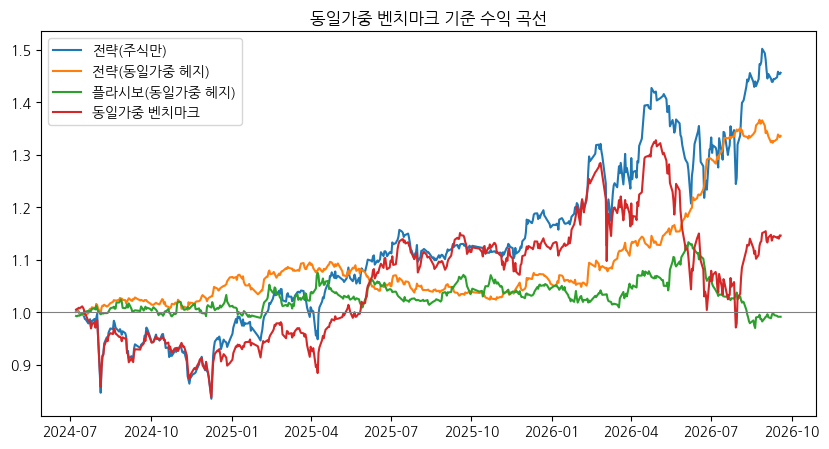


【8-5. 연도별 (동일가중 기준)】


,전략(헤지)%,플라시보(헤지)%,동일가중%,전략-플라시보 %p
2024,6.7,1.1,-9.6,5.6
2025,-1.1,3.4,24.0,-4.5
2026,26.6,-5.1,2.3,31.7



【8-6. 직전 30일 신탁 공시 수 구간별 매매 수익 (동일가중 대비)】


,N,평균%,중앙값%,t,승률%,공시수 최소,공시수 최대
몰림 구간,,,,,,,
적음,232.0,0.45,-0.01,0.77,49.6,0,24
보통,232.0,1.58,1.03,1.86,53.4,24,39
많음,232.0,2.61,0.95,2.92,54.7,39,65


→ "많음" 구간이 확실히 나쁘면, 공시가 몰리는 시기(보통 시장 급락기)를 피하는 규칙을 검토할 수 있음.
  단, 이건 결과를 보고 규칙을 만드는 것이라 전체 기간에서 다시 확인해야 합니다.

8단계 완료 ✅


<Figure size 640x480 with 0 Axes>

In [28]:
from google.colab import files
up = files.upload()                      # "파일 선택" 누르고 step8_addon.py 선택
fname = list(up.keys())[0]
print('업로드된 파일:', fname)
get_ipython().run_line_magic('run', f'-i "{fname}"')

In [29]:
# ===== 전체 기간 실행 (v2 노트북용) — 끊겨도 다시 실행하면 이어서 받음 =====
import os, pickle
from google.colab import drive
drive.mount('/content/drive')
WORK = '/content/drive/MyDrive/disclosure_cache'
os.makedirs(f'{WORK}/cache/dart_list', exist_ok=True); os.chdir(WORK)

QUICK = False
START, END = '2016-01-01', '2026-08-31'
TAG = f'{START}_{END}'
PX_STORE, MISSING = {}, set()
if '_load_px_orig' not in globals():
    _load_px_orig = load_px                      # 원래 가격 함수 보관

def load_px(code, start, end):                   # 저장해 둔 가격이 있으면 그걸 사용
    if code in PX_STORE: return PX_STORE[code]
    if code in MISSING: return None
    return _load_px_orig(code, start, end)

# ---- 1단계: 공시 수집 (85일 구간마다 드라이브에 저장) ----
parts, chunks = [], date_chunks(START, END)
for k, (bgn, en) in enumerate(chunks, 1):
    f = f'cache/dart_list/list_{bgn}_{en}.csv'
    if os.path.exists(f):
        parts.append(pd.read_csv(f, dtype=str)); continue
    df = fetch_disclosures(API_KEY, bgn, en, verbose=False)
    if df.empty:
        df = pd.DataFrame(columns=['corp_code','corp_name','stock_code','corp_cls','report_nm','rcept_no','flr_nm','rcept_dt','rm'])
    df.to_csv(f, index=False); parts.append(df.astype(str))
    print(f'[{k}/{len(chunks)}] {bgn}~{en} {len(df)}건 저장')
raw = pd.concat(parts, ignore_index=True)
events = clean_events(raw, DEDUP_DAYS)
events['period'] = np.where(events.event_date < SPLIT_DATE, f'~{SPLIT_DATE[:4]} 이전', f'{SPLIT_DATE[:4]}~')
print(f'원자료 {len(raw)}건 → 이벤트 {len(events)}건')

# ---- 3단계-1: 주가 받기 (100종목마다 드라이브에 저장) ----
ckpt = f'cache/prices_{TAG}.pkl'
if os.path.exists(ckpt):
    d = pickle.load(open(ckpt, 'rb')); PX_STORE.update(d['px']); MISSING.update(d['missing'])
    print(f'저장된 가격 불러옴: {len(PX_STORE)}종목')
def _save():
    pickle.dump({'px': PX_STORE, 'missing': MISSING}, open(ckpt + '.tmp', 'wb')); os.replace(ckpt + '.tmp', ckpt)
groups = events.groupby('stock_code')
todo = [c for c in groups.groups if c not in PX_STORE and c not in MISSING]
print(f'새로 받을 종목 {len(todo)}개')
for k, code in enumerate(todo, 1):
    sub = groups.get_group(code)
    p = _load_px_orig(code, sub.event_date.min() - pd.Timedelta(days=250), sub.event_date.max() + pd.Timedelta(days=250))
    if p is None: MISSING.add(code)
    else: PX_STORE[code] = p
    if k % 100 == 0:
        _save(); print(f'  {k}/{len(todo)} 저장')
_save()

# ---- 3단계-2: 초과수익률 계산 ----
ev_res, ar_mat = build_ar_matrix(events, PRE, POST, HOLD, COST)
display(ev_res.status.value_counts().to_frame('건수'))
print(f"가격없음 비율 {(ev_res.status == '가격없음').mean():.1%}")
print('전체 기간 준비 완료 ✅')
# ===== 끝 =====

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[1/46] 20160101~20160326 178건 저장
[2/46] 20160327~20160620 151건 저장
[3/46] 20160621~20160914 180건 저장
[4/46] 20160915~20161209 193건 저장
[5/46] 20161210~20170305 182건 저장
[6/46] 20170306~20170530 169건 저장
[7/46] 20170531~20170824 193건 저장
[8/46] 20170825~20171118 191건 저장
[9/46] 20171119~20180212 159건 저장
[10/46] 20180213~20180509 190건 저장
[11/46] 20180510~20180803 185건 저장
[12/46] 20180804~20181028 207건 저장
[13/46] 20181029~20190122 237건 저장
[14/46] 20190123~20190418 179건 저장
[15/46] 20190419~20190713 213건 저장
[16/46] 20190714~20191007 184건 저장
[17/46] 20191008~20200101 183건 저장
[18/46] 20200102~20200327 552건 저장
[19/46] 20200328~20200621 167건 저장
[20/46] 20200622~20200915 203건 저장
[21/46] 20200916~20201210 254건 저장
[22/46] 20201211~20210306 159건 저장
[23/46] 20210307~20210531 188건 저장
[24/46] 20210601~20210825 119건 저장
[25/46] 20210826~20211119 211건 저장
[26/46] 20211120~20220213 143건

,건수
status,
ok,4115
기간밖,21
기업행위의심,3
가격없음,2


가격없음 비율 0.0%
전체 기간 준비 완료 ✅


통과: test_portfolio_backtest ✅
신호 1684건, 플라시보 1683건


,연수익률%,변동성%,샤프,최대낙폭%,누적%
전략(주식만),18.08,17.84,1.02,-33.80,460.8
전략(지수 헤지),16.51,10.68,1.48,-18.66,388.1
플라시보(주식만),2.96,17.48,0.25,-36.60,35.4
플라시보(지수 헤지),-1.87,11.39,-0.11,-48.99,-17.8
KOSDAQ 지수,1.82,26.62,0.20,-53.79,20.6


평균 보유 종목 12.9개 / 투자 비중 평균 54% (나머지는 현금) / 종목이 하나도 없던 날 1%


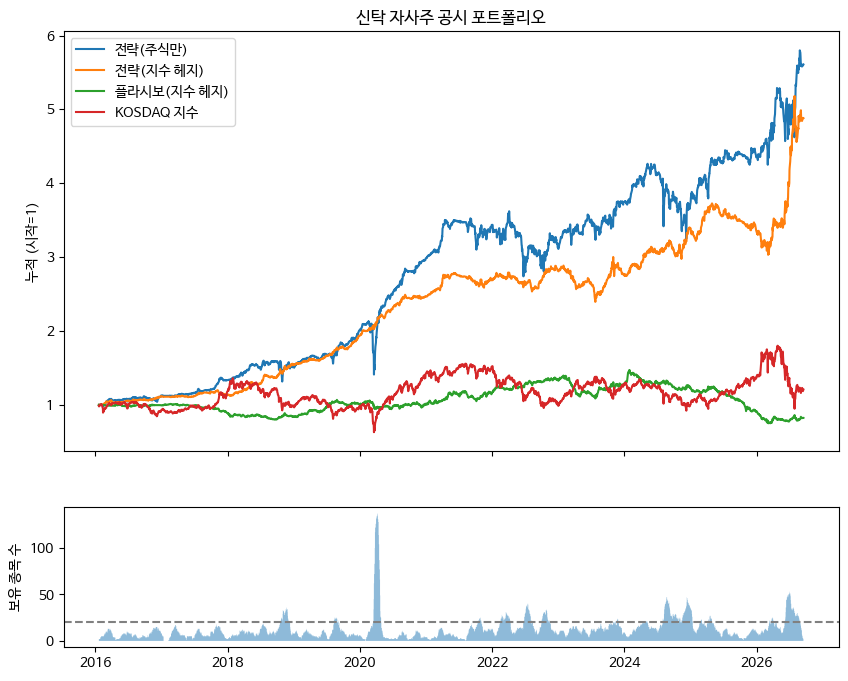

,전략(주식만)%,전략(헤지)%,플라시보(헤지)%,KOSDAQ%,평균 보유 종목
2016,12.6,11.7,-0.8,-7.3,7.073
2017,18.3,1.7,-10.5,26.4,7.383
2018,14.2,35.6,-5.5,-15.4,12.004
2019,32.0,25.3,19.8,-0.9,8.455
2020,48.5,27.6,-0.6,44.6,16.165
2021,15.1,9.2,15.9,6.8,8.560
2022,-8.8,4.6,16.5,-34.3,18.138
2023,19.6,-1.8,-5.5,27.6,12.527
2024,-1.1,22.5,-3.4,-21.7,20.697
2025,17.5,-0.9,-26.2,36.5,11.798


,연수익률%,변동성%,샤프,최대낙폭%,누적%
슬롯 10 / 비용 0.3%,22.47,15.00,1.43,-32.15,719.0
슬롯 10 / 비용 1.0%,14.03,15.00,0.95,-35.90,290.7
슬롯 20 / 비용 0.3%,16.51,10.68,1.48,-18.66,388.1
슬롯 20 / 비용 1.0%,11.02,10.67,1.03,-23.44,195.9
슬롯 40 / 비용 0.3%,10.61,6.72,1.53,-9.69,184.7
슬롯 40 / 비용 1.0%,7.64,6.71,1.13,-11.44,114.8


하루 거래대금의 5%만 산다고 할 때 한 종목에 넣을 수 있는 금액
  하위 25%: 14백만 원 / 중앙값: 38백만 원
→ 종목당 비중 1/20이면, 대부분의 종목을 제대로 살 수 있는 포트폴리오 규모 ≈ 2.8억 원 (하위 25% 기준)
  이보다 크면 소형주에서 원하는 만큼 못 사거나, 사는 순간 가격을 밀어 올려 수익이 줄어듭니다.

7단계 완료 ✅
통과: test_ew_benchmark ✅
【8-1. 시가총액 지수 점검】

KOSPI: 연도별 변동성(%) {2015: 13.8, 2016: 12.2, 2017: 9.3, 2018: 14.4, 2019: 12.6, 2020: 28.3, 2021: 16.4, 2022: 18.6, 2023: 15.4, 2024: 19.6, 2025: 21.5, 2026: 62.2}
  ⚠️ 하루 ±8% 넘는 날 13일 — 실제 폭락/폭등인지, 데이터 오류인지 확인 필요:


,일간 변동%
Date,
2020-03-19,-8.39
2020-03-24,8.60
2024-08-05,-8.77
2026-03-04,-12.06
2026-03-05,9.63
2026-04-01,8.44
2026-05-21,8.42
2026-06-08,-8.29
2026-06-09,8.18



KOSDAQ: 연도별 변동성(%) {2015: 23.7, 2016: 17.7, 2017: 14.5, 2018: 25.2, 2019: 19.6, 2020: 34.3, 2021: 18.1, 2022: 27.0, 2023: 23.4, 2024: 24.6, 2025: 21.1, 2026: 55.3}
  ⚠️ 하루 ±8% 넘는 날 9일 — 실제 폭락/폭등인지, 데이터 오류인지 확인 필요:


...


【8-2. 동일가중 벤치마크】
KOSPI: 하루 평균 160개 종목으로 구성
KOSDAQ: 하루 평균 312개 종목으로 구성
※ 자사주 공시 기업 전체(미래에 공시할 기업 포함)로 만든 비교 기준입니다. 매매 신호가 아니라 비교용이므로 문제없습니다.

【8-3. 동일가중 대비 매매 수익 (t0+1 진입, 20일 보유, 비용 반영)】


,공시 N,공시 평균%,공시 중앙값%,무작위 평균%,차이%p,차이 t
그룹,,,,,,
KOSDAQ-신탁,1688,1.91,0.40,-0.66,2.58,7.22
KOSDAQ-직접,904,1.05,-0.15,-0.61,1.66,3.40
KOSPI-신탁,785,1.28,0.49,-0.61,1.89,4.82
KOSPI-직접,751,0.98,-0.34,-0.45,1.43,2.85


→ 이제 "무작위 평균"이 0 근처여야 정상. 여전히 크게 마이너스면 벤치마크로도 설명 안 되는 무언가가 있음.

【8-4. 포트폴리오 성과 (동일가중 기준)】


,연수익률%,변동성%,샤프,최대낙폭%,누적%
전략(주식만),18.19,17.84,1.03,-33.80,466.8
전략(동일가중 헤지),13.34,6.86,1.86,-12.24,267.1
플라시보(주식만),2.96,17.48,0.25,-36.60,35.4
플라시보(동일가중 헤지),-2.88,8.36,-0.31,-35.66,-26.2
동일가중 벤치마크,6.33,19.74,0.41,-45.22,89.1


<Figure size 640x480 with 0 Axes>

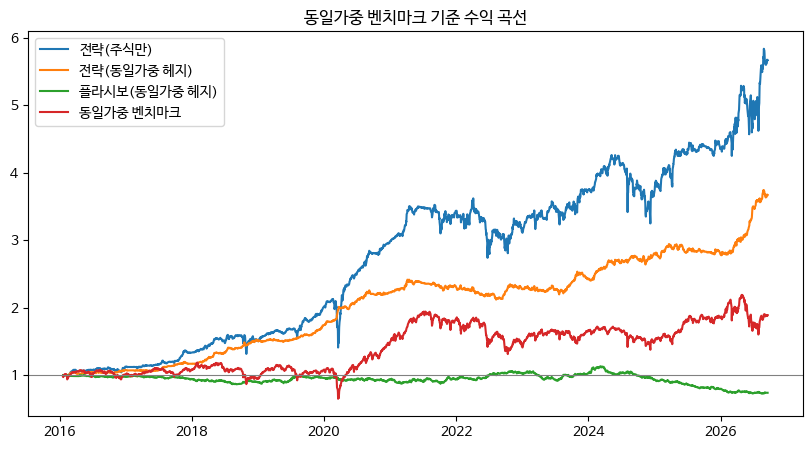


【8-5. 연도별 (동일가중 기준)】


,전략(헤지)%,플라시보(헤지)%,동일가중%,전략-플라시보 %p
2016,7.8,-2.6,1.3,10.4
2017,8.4,-3.2,6.3,11.6
2018,29.3,-5.1,-10.7,34.4
2019,15.1,7.0,12.1,8.1
2020,28.1,-2.6,37.9,30.7
2021,3.6,0.8,23.4,2.8
2022,-1.4,10.0,-21.8,-11.4
2023,7.0,-1.0,15.5,8.0
2024,15.3,-8.5,-10.4,23.8
2025,-0.3,-15.1,24.4,14.8



【8-6. 직전 30일 신탁 공시 수 구간별 매매 수익 (동일가중 대비)】


,N,평균%,중앙값%,t,승률%,공시수 최소,공시수 최대
몰림 구간,,,,,,,
적음,561.0,2.69,0.85,4.27,53.7,1,16
보통,561.0,1.68,0.54,3.57,52.8,16,30
많음,562.0,1.41,-0.27,2.33,49.5,30,183


→ "많음" 구간이 확실히 나쁘면, 공시가 몰리는 시기(보통 시장 급락기)를 피하는 규칙을 검토할 수 있음.
  단, 이건 결과를 보고 규칙을 만드는 것이라 전체 기간에서 다시 확인해야 합니다.

8단계 완료 ✅


<Figure size 640x480 with 0 Axes>

In [30]:
!sed -i "s/SIG_MARKETS = \['KOSDAQ', 'KOSPI'\]/SIG_MARKETS = ['KOSDAQ']/" step7_addon.py
%run -i step7_addon.py
%run -i step8_addon.py

In [32]:
# ===== 9단계: 위기 때만 작동하나? =====
CRISIS_YEARS = [2018, 2020, 2022, 2026]
d = yr8['전략-플라시보 %p']
display(d.to_frame().assign(위기연도=d.index.isin(CRISIS_YEARS)))
cr, nc = d[d.index.isin(CRISIS_YEARS)], d[~d.index.isin(CRISIS_YEARS)]
print(f'위기 연도 {list(cr.index)}: 평균 {cr.mean():+.1f}%p, 플러스 {int((cr > 0).sum())}/{len(cr)}')
print(f'나머지 연도 {list(nc.index)}: 평균 {nc.mean():+.1f}%p, 플러스 {int((nc > 0).sum())}/{len(nc)}')
if (cr > 0).mean() >= 0.75 and cr.mean() - nc.mean() > 3:
    print('→ "평소 알파"가 아니라 "폭락장에서 작동하는 신호"에 가까움')
elif (d > 0).mean() >= 0.7:
    print('→ 위기 여부와 관계없이 대부분의 해에 작동. 강한 신호 후보')
else:
    print('→ 특정 해에 몰려 있어 일관된 신호로 보기 어려움. 사례 연구로 정리하는 편이 정직')
print(f'※ 위기 연도가 {len(cr)}개뿐이라 효과가 없어도 우연히 전부 플러스일 확률 1/{2**len(cr)}')

,전략-플라시보 %p,위기연도
2016,10.4,False
2017,11.6,False
2018,34.4,True
2019,8.1,False
2020,30.7,True
2021,2.8,False
2022,-11.4,True
2023,8.0,False
2024,23.8,False
2025,14.8,False


위기 연도 [2018, 2020, 2022, 2026]: 평균 +23.0%p, 플러스 3/4
나머지 연도 [2016, 2017, 2019, 2021, 2023, 2024, 2025]: 평균 +11.4%p, 플러스 7/7
→ "평소 알파"가 아니라 "폭락장에서 작동하는 신호"에 가까움
※ 위기 연도가 4개뿐이라 효과가 없어도 우연히 전부 플러스일 확률 1/16


## 결과를 믿기 전 체크리스트
1. **테스트 전부 통과**했나
2. **가격없음 비율**이 작나 (크면 생존편향)
3. **평균과 중앙값**이 같은 방향인가 (몇 개 급등주가 평균을 끌어올린 건 아닌가)
4. **t(날짜군집)**으로도 유의한가
5. **기간 분할**에서 앞뒤가 같은 방향인가
6. **5단계 매매**에서 비용을 빼고도 남는가 — 반응[0,+1]이 커도 따라 살 수 있는 구간이 아니면 돈이 안 됩니다
7. 조건을 여러 개 쪼갰다면, 그중 하나만 좋은 건 **우연**일 수 있음

다음 공시 유형(유상증자, 전환사채, 공급계약)은 `fetch_disclosures(..., keyword='유상증자')`처럼 키워드와 `clean_events` 분류만 바꾸면 같은 엔진으로 돌릴 수 있습니다.